<a href="https://colab.research.google.com/github/yeshaa23/Project-A-Kelompok-4-Pertamina-PBAGenap/blob/main/Nottebook/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from matplotlib.ticker import MaxNLocator

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load data hasil preprocessing

In [3]:
# Path ke file di Google Drive
file_path = '/content/drive/MyDrive/ProjectA-PBA/hasil_preprocessing_pertamina.csv'

# Baca data ke DataFrame
df = pd.read_csv(file_path)
df.head()

,Link,Judul,Isi Berita,Status,Tag,Sentimen,Penerbit,text_uppercase,text_lowercase,text_clean,text_no_boilerplate,tokens_before_sw,jumlah_token_before_sw,text_no_stopwords,tokens_after_sw,jumlah_token_after_sw,tokenisasi,text_stemmed,tokens_stemmed
0,https://money.kompas.com/image/2017/10/03/1815...,Foto : CSR Pertamina Lubricants Kini Fokus ke ...,Diskusi mengenai CSR di industri pelumas berta...,success,Ekonomi,Netral,money.kompas.com,DISKUSI MENGENAI CSR DI INDUSTRI PELUMAS BERTA...,diskusi mengenai csr di industri pelumas berta...,diskusi mengenai csr industri pelumas bertajuk...,diskusi mengenai csr industri pelumas bertajuk...,"['diskusi', 'mengenai', 'csr', 'industri', 'pe...",16,diskusi mengenai csr industri pelumas bertajuk...,"['diskusi', 'mengenai', 'csr', 'industri', 'pe...",13,diskusi | mengenai | csr | industri | pelumas ...,diskusi kena csr industri lumas tajuk cari for...,"['diskusi', 'kena', 'csr', 'industri', 'lumas'..."
1,https://money.kompas.com/read/2016/06/06/14280...,"Gandeng Dua Bank, Pertamina Lubricants Yakin P...","JAKARTA, KOMPAS.com - Anak perusahaan Pertamin...",success,Kecelakaan Kerja,Positif,money.kompas.com,"JAKARTA, KOMPAS.COM - ANAK PERUSAHAAN PERTAMIN...","jakarta, kompas.com - anak perusahaan pertamin...",jakarta kompas com anak perusahaan pertamina y...,anak perusahaan pertamina yakni pertamina lubr...,"['anak', 'perusahaan', 'pertamina', 'yakni', '...",130,anak perusahaan pertamina pertamina lubricants...,"['anak', 'perusahaan', 'pertamina', 'pertamina...",95,anak | perusahaan | pertamina | pertamina | lu...,anak usaha pertamina pertamina lubricants gand...,"['anak', 'usaha', 'pertamina', 'pertamina', 'l..."
2,https://money.kompas.com/image/2017/08/03/0900...,"Foto : Cegah Kepunahan, Pertamina Lestarikan T...",Pelepasan Indukan Tuntong Laut oleh tim konser...,success,Bisnis,Positif,money.kompas.com,PELEPASAN INDUKAN TUNTONG LAUT OLEH TIM KONSER...,pelepasan indukan tuntong laut oleh tim konser...,pelepasan indukan tuntong laut oleh tim konser...,pelepasan indukan tuntong laut oleh tim konser...,"['pelepasan', 'indukan', 'tuntong', 'laut', 'o...",34,pelepasan indukan tuntong laut tim konservasi ...,"['pelepasan', 'indukan', 'tuntong', 'laut', 't...",31,pelepasan | indukan | tuntong | laut | tim | k...,lepas indu tuntong laut tim konservasi alam pe...,"['lepas', 'indu', 'tuntong', 'laut', 'tim', 'k..."
3,https://money.kompas.com/read/2016/04/11/17345...,Pertamina Menaikkan Ongkos Angkut Minyak Penam...,"BOJONEGORO, KOMPAS.com - Pemerintah terus meng...",success,Migas,Positif,money.kompas.com,"BOJONEGORO, KOMPAS.COM - PEMERINTAH TERUS MENG...","bojonegoro, kompas.com - pemerintah terus meng...",bojonegoro kompas com pemerintah terus mengupa...,bojonegoro pemerintah terus mengupayakan penam...,"['bojonegoro', 'pemerintah', 'terus', 'mengupa...",307,bojonegoro pemerintah terus mengupayakan penam...,"['bojonegoro', 'pemerintah', 'terus', 'mengupa...",229,bojonegoro | pemerintah | terus | mengupayakan...,bojonegoro perintah terus upaya tambah produks...,"['bojonegoro', 'perintah', 'terus', 'upaya', '..."
4,https://money.kompas.com/image/2017/11/27/1656...,Foto : Ini Dua Fokus CSR Pertamina Patra Niaga...,Direktur Operasional PT Pertamina Patra Niaga ...,success,Akademik,Positif,money.kompas.com,DIREKTUR OPERASIONAL PT PERTAMINA PATRA NIAGA ...,direktur operasional pt pertamina patra niaga ...,direktur operasional pertamina patra niaga abd...,direktur operasional pertamina patra niaga abd...,"['direktur', 'operasional', 'pertamina', 'patr...",38,operasional pertamina patra niaga abdul cholid...,"['operasional', 'pertamina', 'patra', 'niaga',...",32,operasional | pertamina | patra | niaga | abdu...,operasional pertamina patra niaga abdul cholid...,"['operasional', 'pertamina', 'patra', 'niaga',..."


## Informasi dasar dataset

In [19]:
print("===== Info Dataset =====")
print(df.info())
print("\n===== 5 Baris Pertama =====")
display(df.head())
print("\n===== Statistik Deskriptif =====")
display(df.describe())
print("\nJumlah duplikat:", df.duplicated().sum())
print("\nMissing value per kolom:")
print(df.isnull().sum())

===== Info Dataset =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Link                    1566 non-null   object
 1   Judul                   1566 non-null   object
 2   Isi Berita              1513 non-null   object
 3   Status                  1567 non-null   object
 4   Tag                     1566 non-null   object
 5   Sentimen                1567 non-null   object
 6   Penerbit                1566 non-null   object
 7   text_uppercase          1567 non-null   object
 8   text_lowercase          1513 non-null   object
 9   text_clean              1513 non-null   object
 10  text_no_boilerplate     1513 non-null   object
 11  tokens_before_sw        1567 non-null   object
 12  jumlah_token_before_sw  1567 non-null   int64 
 13  text_no_stopwords       1513 non-null   object
 14  tokens_after_sw         1567 no

,Link,Judul,Isi Berita,Status,Tag,Sentimen,Penerbit,text_uppercase,text_lowercase,text_clean,text_no_boilerplate,tokens_before_sw,jumlah_token_before_sw,text_no_stopwords,tokens_after_sw,jumlah_token_after_sw,tokenisasi,text_stemmed,tokens_stemmed
0,https://money.kompas.com/image/2017/10/03/1815...,Foto : CSR Pertamina Lubricants Kini Fokus ke ...,Diskusi mengenai CSR di industri pelumas berta...,success,Ekonomi,Netral,money.kompas.com,DISKUSI MENGENAI CSR DI INDUSTRI PELUMAS BERTA...,diskusi mengenai csr di industri pelumas berta...,diskusi mengenai csr industri pelumas bertajuk...,diskusi mengenai csr industri pelumas bertajuk...,"['diskusi', 'mengenai', 'csr', 'industri', 'pe...",16,diskusi mengenai csr industri pelumas bertajuk...,"['diskusi', 'mengenai', 'csr', 'industri', 'pe...",13,diskusi | mengenai | csr | industri | pelumas ...,diskusi kena csr industri lumas tajuk cari for...,"['diskusi', 'kena', 'csr', 'industri', 'lumas'..."
1,https://money.kompas.com/read/2016/06/06/14280...,"Gandeng Dua Bank, Pertamina Lubricants Yakin P...","JAKARTA, KOMPAS.com - Anak perusahaan Pertamin...",success,Kecelakaan Kerja,Positive,money.kompas.com,"JAKARTA, KOMPAS.COM - ANAK PERUSAHAAN PERTAMIN...","jakarta, kompas.com - anak perusahaan pertamin...",jakarta kompas com anak perusahaan pertamina y...,anak perusahaan pertamina yakni pertamina lubr...,"['anak', 'perusahaan', 'pertamina', 'yakni', '...",130,anak perusahaan pertamina pertamina lubricants...,"['anak', 'perusahaan', 'pertamina', 'pertamina...",95,anak | perusahaan | pertamina | pertamina | lu...,anak usaha pertamina pertamina lubricants gand...,"['anak', 'usaha', 'pertamina', 'pertamina', 'l..."
2,https://money.kompas.com/image/2017/08/03/0900...,"Foto : Cegah Kepunahan, Pertamina Lestarikan T...",Pelepasan Indukan Tuntong Laut oleh tim konser...,success,Bisnis,Positive,money.kompas.com,PELEPASAN INDUKAN TUNTONG LAUT OLEH TIM KONSER...,pelepasan indukan tuntong laut oleh tim konser...,pelepasan indukan tuntong laut oleh tim konser...,pelepasan indukan tuntong laut oleh tim konser...,"['pelepasan', 'indukan', 'tuntong', 'laut', 'o...",34,pelepasan indukan tuntong laut tim konservasi ...,"['pelepasan', 'indukan', 'tuntong', 'laut', 't...",31,pelepasan | indukan | tuntong | laut | tim | k...,lepas indu tuntong laut tim konservasi alam pe...,"['lepas', 'indu', 'tuntong', 'laut', 'tim', 'k..."
3,https://money.kompas.com/read/2016/04/11/17345...,Pertamina Menaikkan Ongkos Angkut Minyak Penam...,"BOJONEGORO, KOMPAS.com - Pemerintah terus meng...",success,Migas,Positive,money.kompas.com,"BOJONEGORO, KOMPAS.COM - PEMERINTAH TERUS MENG...","bojonegoro, kompas.com - pemerintah terus meng...",bojonegoro kompas com pemerintah terus mengupa...,bojonegoro pemerintah terus mengupayakan penam...,"['bojonegoro', 'pemerintah', 'terus', 'mengupa...",307,bojonegoro pemerintah terus mengupayakan penam...,"['bojonegoro', 'pemerintah', 'terus', 'mengupa...",229,bojonegoro | pemerintah | terus | mengupayakan...,bojonegoro perintah terus upaya tambah produks...,"['bojonegoro', 'perintah', 'terus', 'upaya', '..."
4,https://money.kompas.com/image/2017/11/27/1656...,Foto : Ini Dua Fokus CSR Pertamina Patra Niaga...,Direktur Operasional PT Pertamina Patra Niaga ...,success,Akademik,Positive,money.kompas.com,DIREKTUR OPERASIONAL PT PERTAMINA PATRA NIAGA ...,direktur operasional pt pertamina patra niaga ...,direktur operasional pertamina patra niaga abd...,direktur operasional pertamina patra niaga abd...,"['direktur', 'operasional', 'pertamina', 'patr...",38,operasional pertamina patra niaga abdul cholid...,"['operasional', 'pertamina', 'patra', 'niaga',...",32,operasional | pertamina | patra | niaga | abdu...,operasional pertamina patra niaga abdul cholid...,"['operasional', 'pertamina', 'patra', 'niaga',..."



===== Statistik Deskriptif =====


,jumlah_token_before_sw,jumlah_token_after_sw
count,1567.000000,1567.000000
mean,324.645820,244.310785
std,221.961493,161.742194
min,1.000000,1.000000
25%,212.000000,161.000000
50%,300.000000,226.000000
75%,395.000000,295.000000
max,2027.000000,1673.000000



Jumlah duplikat: 2

Missing value per kolom:
Link                       1
Judul                      1
Isi Berita                54
Status                     0
Tag                        1
Sentimen                   0
Penerbit                   1
text_uppercase             0
text_lowercase            54
text_clean                54
text_no_boilerplate       54
tokens_before_sw           0
jumlah_token_before_sw     0
text_no_stopwords         54
tokens_after_sw            0
jumlah_token_after_sw      0
tokenisasi                54
text_stemmed              54
tokens_stemmed             0
dtype: int64


## Visualisasi

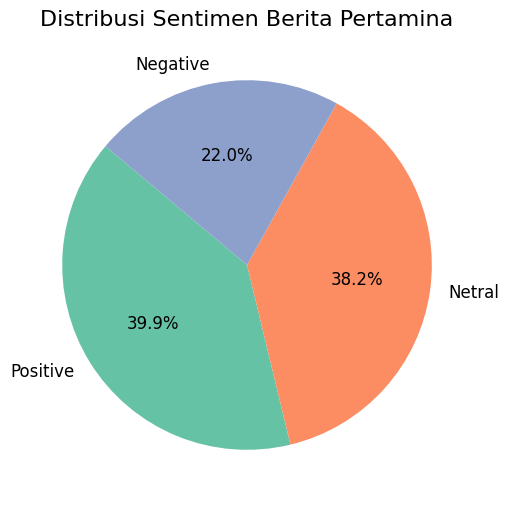

In [20]:
# Visualisasi Distribusi Sentimen
plt.figure(figsize=(8,6))
colors = ['#66c2a5', '#fc8d62', '#8da0cb']  # Hijau, Orange, Biru
df['Sentimen'].value_counts().plot.pie(autopct='%1.1f%%', colors=colors, startangle=140, textprops={'fontsize':12})
plt.title('Distribusi Sentimen Berita Pertamina', fontsize=16)
plt.ylabel('')
plt.show()

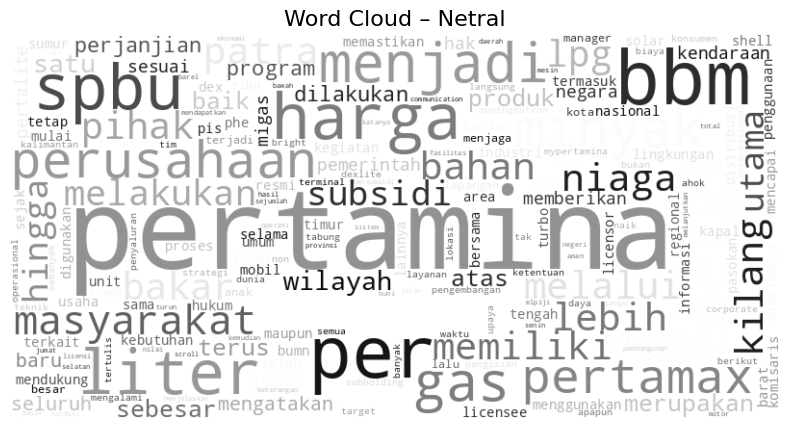

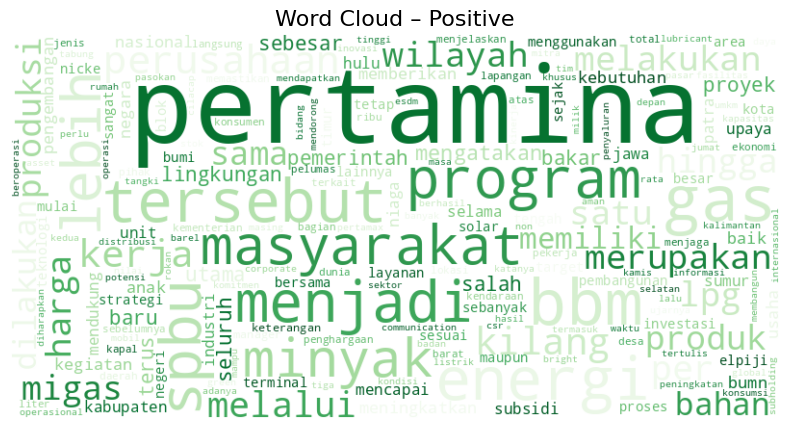

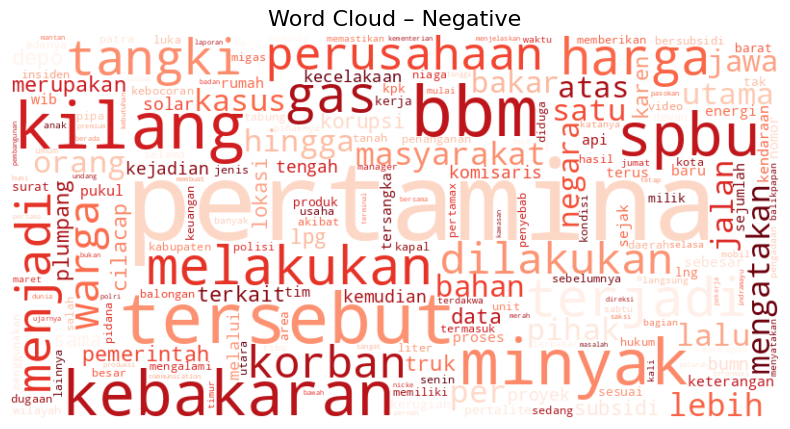

In [22]:
# Visualisasi Word Cloud per Sentimen
df['Sentimen'] = df['Sentimen'].replace({'Positif': 'Positive', 'Negatif': 'Negative'})

sentiments = df['Sentimen'].unique()
color_maps = {'Positive':'Greens', 'Negative':'Reds', 'Neutral':'Blues'}

for sentiment in sentiments:
    text = ' '.join(df[df['Sentimen']==sentiment]['text_no_stopwords'].dropna())
    if text:
        wc = WordCloud(width=800, height=400, background_color='white',
                       colormap=color_maps.get(sentiment, 'Greys'), collocations=False).generate(text)
        plt.figure(figsize=(10,5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Word Cloud – {sentiment}', fontsize=16)
        plt.show()

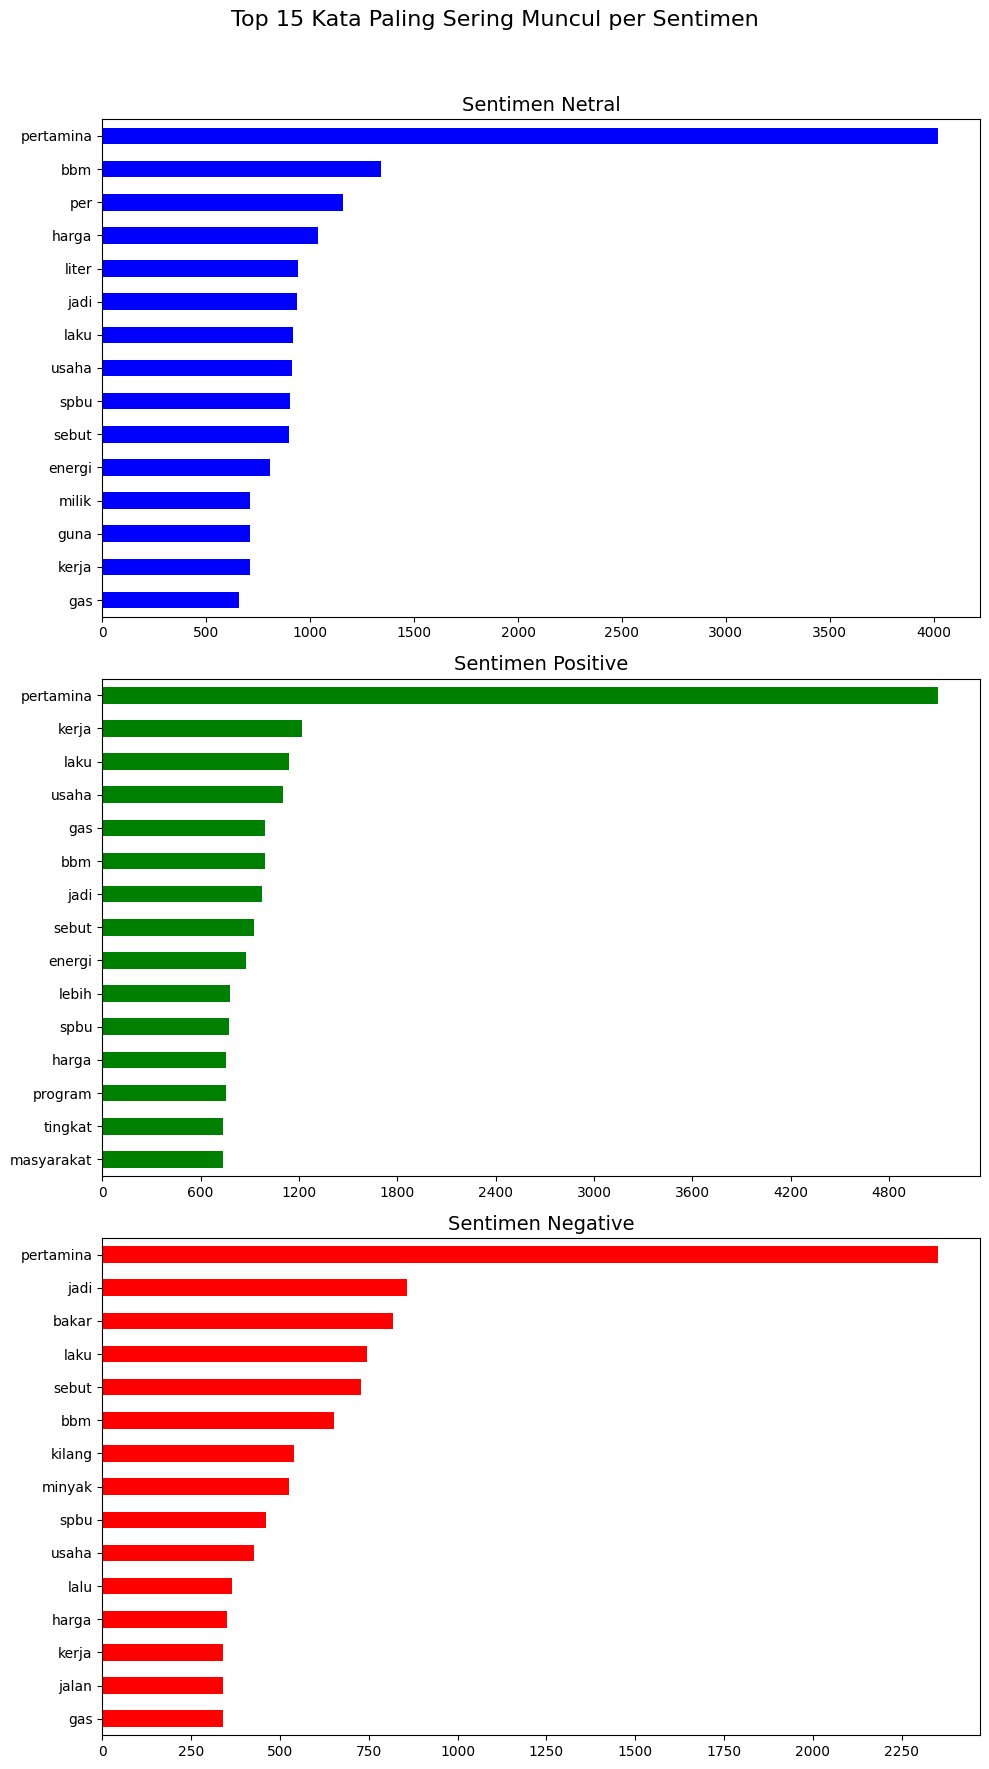

In [26]:
# Visualisasi Frekuensi Kata Teratas per Sentimen
df['Sentimen'] = df['Sentimen'].replace({'Positif': 'Positive', 'Negatif': 'Negative'})

# Get unique sentiments after harmonization
sentiments_harmonized = df['Sentimen'].unique()

# Dynamically create subplots based on the number of unique sentiments
fig, axes = plt.subplots(len(sentiments_harmonized), 1, figsize=(10, 6 * len(sentiments_harmonized)))
if len(sentiments_harmonized) == 1:
    axes = [axes]

fig.suptitle('Top 15 Kata Paling Sering Muncul per Sentimen', fontsize=16)
color_maps_for_plot = {
    'positive': 'green',
    'negative': 'red',
    'netral': 'blue'
}

for i, sentiment in enumerate(sentiments_harmonized):
    corpus = ' '.join(df[df['Sentimen'] == sentiment]['text_stemmed'].dropna())
    words = corpus.split()
    word_freq = pd.Series(words).value_counts().head(15)

    ax = axes[i]
    plot_color = color_maps_for_plot.get(sentiment.lower(), 'gray')
    word_freq.sort_values().plot(kind='barh', ax=ax, color=plot_color)
    ax.set_title(f'Sentimen {sentiment.capitalize()}', fontsize=14)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

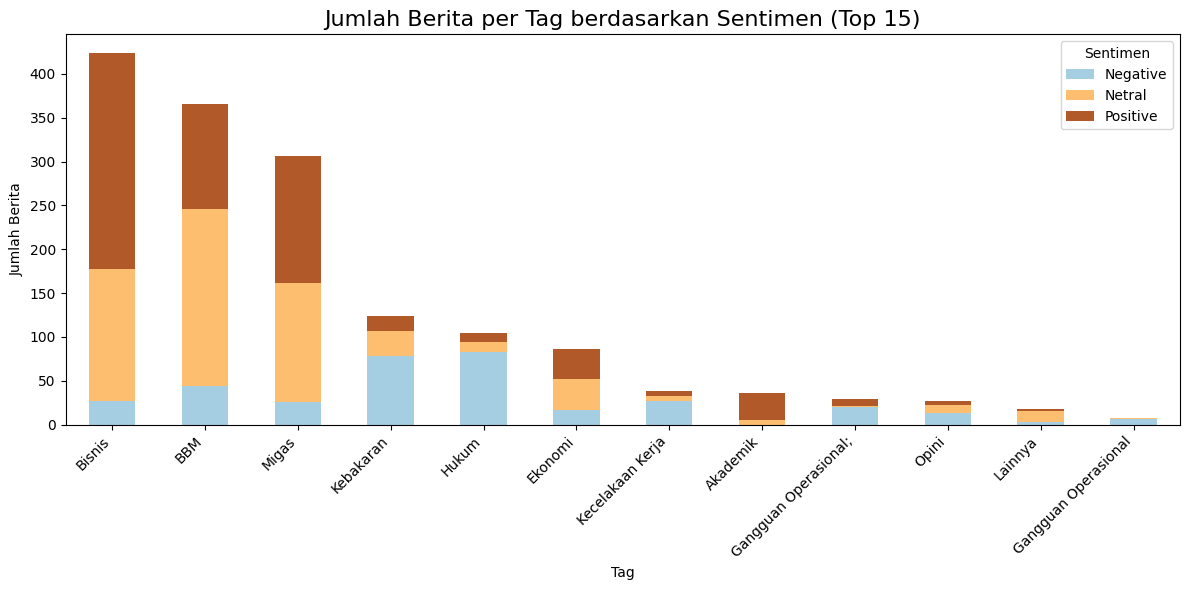

In [32]:
# Distribusi sentiment berdasarkan Tag
tag_sentiment_counts = df.groupby(['Tag', 'Sentimen']).size().unstack(fill_value=0)

# Ambil 15 Tag terbanyak
top_tags = df['Tag'].value_counts().head(15).index
tag_sentiment_counts.loc[top_tags].plot(kind='bar', stacked=True, figsize=(12,6), colormap='Paired')

plt.title('Jumlah Berita per Tag berdasarkan Sentimen (Top 15)', fontsize=16)
plt.xlabel('Tag')
plt.ylabel('Jumlah Berita')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentimen')
plt.tight_layout()
plt.show()

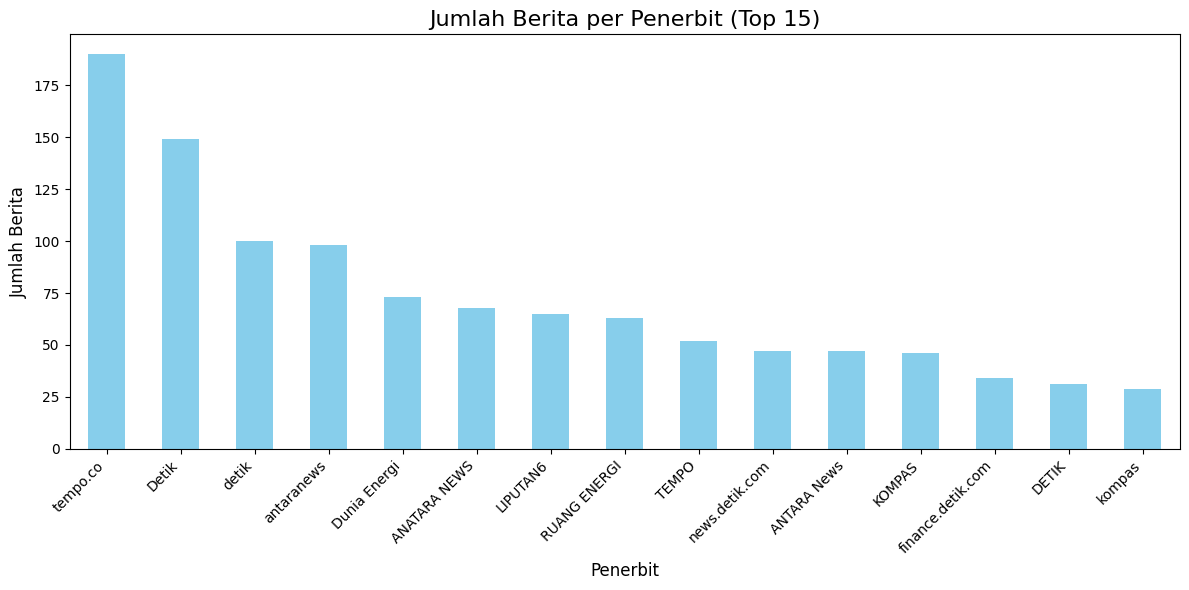

In [33]:
# Hitung jumlah berita per penerbit
top_publishers = df['Penerbit'].value_counts().head(15)  # ambil 15 teratas

# Buat bar chart
plt.figure(figsize=(12,6))
top_publishers.plot(kind='bar', color='skyblue')
plt.title('Jumlah Berita per Penerbit (Top 15)', fontsize=16)
plt.xlabel('Penerbit', fontsize=12)
plt.ylabel('Jumlah Berita', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

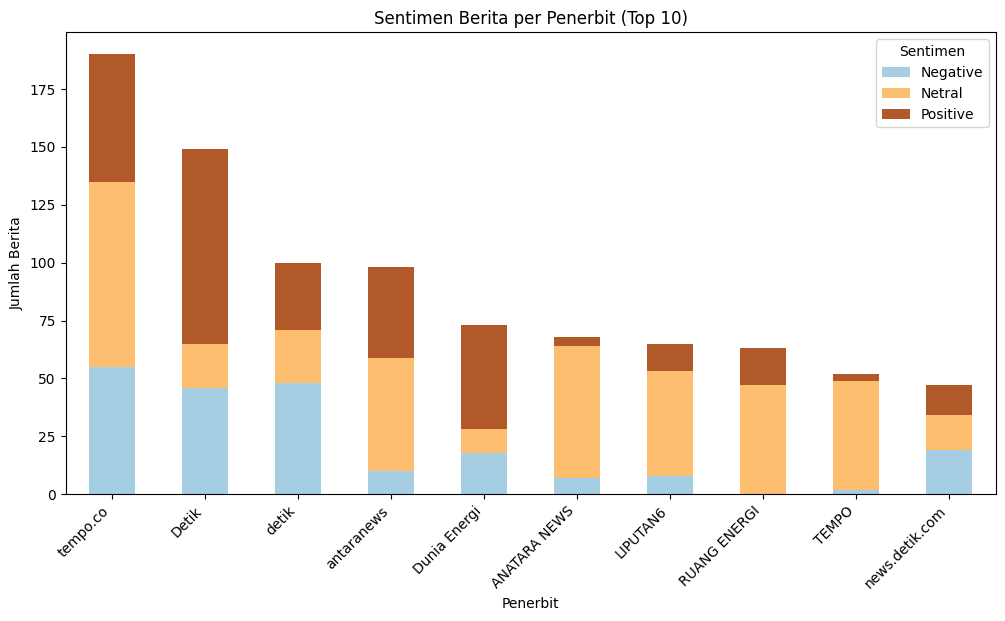

In [34]:
# Distribusi sentiment berdasarkan penerbit
publisher_sentiment = df.groupby(['Penerbit','Sentimen']).size().unstack(fill_value=0)

# Bisa ambil top 10 penerbit
top_publishers = df['Penerbit'].value_counts().head(10).index
publisher_sentiment.loc[top_publishers].plot(kind='bar', stacked=True, figsize=(12,6), colormap='Paired')
plt.title('Sentimen Berita per Penerbit (Top 10)')
plt.xlabel('Penerbit')
plt.ylabel('Jumlah Berita')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
# Tren sentiment
df['Tanggal_Format'] = pd.to_datetime(df['Tanggal'], errors='coerce')
df_time = df.dropna(subset=['Tanggal_Format']).copy()
df_time.set_index('Tanggal_Format', inplace=True)
trend = df_time.groupby([pd.Grouper(freq='M'), 'Sentimen']).size().unstack(fill_value=0)
plt.figure(figsize=(14,7))
trend.plot(kind='line', marker='o')
plt.title('Tren Sentimen Berita Pertamina per Bulan', fontsize=16)
plt.xlabel('Bulan')
plt.ylabel('Jumlah Berita')
plt.grid(True)
plt.legend(title='Sentimen')
plt.show()

## Simpan hasil

In [ ]:
output_path = '/content/drive/MyDrive/ProjectA-PBA/hasil_eda_pertamina.csv'
df.to_csv(output_path, index=False, encoding='utf-8')
print(f"Hasil EDA tersimpan")